In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras import layers, models

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [ ]:
# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================================================
# FOLDER PENYIMPANAN
# =========================================================

save_dir = "/content/drive/MyDrive/hasil_training"

os.makedirs(save_dir, exist_ok=True)

print("Folder penyimpanan siap")

Folder penyimpanan siap


In [ ]:
# =========================================================
# COPY DATASET KE COLAB
# =========================================================

src = "/content/drive/MyDrive/dataset_buah"
dst = "/content/dataset"

if not os.path.exists(dst):
    print("Menyalin dataset...")
    shutil.copytree(src, dst)
    print("Selesai copy")
else:
    print("Dataset sudah ada")


Dataset sudah ada


In [ ]:
# =========================================================
# PATH DATASET
# =========================================================

dataset_path = dst

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

print("Isi folder train:")
print(os.listdir(train_dir))

print("\nIsi folder test:")
print(os.listdir(test_dir))


Isi folder train:
['freshapples', 'rottenbanana', 'rottenapples', 'freshoranges', 'rottenoranges', 'freshbanana']

Isi folder test:
['freshapples', 'rottenbanana', 'rottenapples', 'freshoranges', 'rottenoranges', 'freshbanana']


In [ ]:
# =========================================================
# PARAMETER
# =========================================================

IMG_SIZE = (224, 224)

BATCH_SIZE = 64

EPOCHS = 15

TANPA AUGMENTASI

In [ ]:
# =========================================================
# DATASET TANPA AUGMENTASI
# =========================================================

datagen_no_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.1
)

train_no_aug = datagen_no_aug.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_no_aug = datagen_no_aug.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_no_aug = datagen_no_aug.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 9813 images belonging to 6 classes.
Found 1088 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.


In [ ]:
# =========================================================
# MODEL TANPA AUGMENTASI
# =========================================================

base_model_no_aug = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_no_aug.trainable = False

model_no_aug = models.Sequential([
    base_model_no_aug,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_no_aug.num_classes, activation='softmax')
])

model_no_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# =========================================================
# CALLBACK
# =========================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint_no_aug = ModelCheckpoint(
    filepath=os.path.join(save_dir, "best_model_no_aug.h5"),
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [ ]:
# =========================================================
# TRAINING TANPA AUGMENTASI
# =========================================================

history_no_aug = model_no_aug.fit(
    train_no_aug,
    validation_data=val_no_aug,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint_no_aug]
)

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.4532 - loss: 1.4628
Epoch 1: val_accuracy improved from None to 0.95404, saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5



Epoch 1: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 132s 705ms/step - accuracy: 0.6533 - loss: 0.9464 - val_accuracy: 0.9540 - val_loss: 0.2284 - learning_rate: 1.0000e-04
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8789 - loss: 0.3689
Epoch 2: val_accuracy improved from 0.95404 to 0.97243, saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5



Epoch 2: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 65s 419ms/step - accuracy: 0.8951 - loss: 0.3199 - val_accuracy: 0.9724 - val_loss: 0.1197 - learning_rate: 1.0000e-04
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9265 - loss: 0.2257
Epoch 3: val_accuracy improved from 0.97243 to 0.97518, saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5



Epoch 3: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 63s 410ms/step - accuracy: 0.9313 - loss: 0.2107 - val_accuracy: 0.9752 - val_loss: 0.0872 - learning_rate: 1.0000e-04
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9401 - loss: 0.1811
Epoch 4: val_accuracy improved from 0.97518 to 0.97702, saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5



Epoch 4: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 61s 398ms/step - accuracy: 0.9438 - loss: 0.1685 - val_accuracy: 0.9770 - val_loss: 0.0719 - learning_rate: 1.0000e-04
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9500 - loss: 0.1429
Epoch 5: val_accuracy improved from 0.97702 to 0.98438, saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 62s 402ms/step - accuracy: 0.9598 - loss: 0.1199 - val_accuracy: 0.9871 - val_loss: 0.0507 - learning_rate: 1.0000e-04
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9638 - loss: 0.1142
Epoch 7: val_accuracy did not improve from 0.98713
154/154 ━━━━━━━━━━━━━━━━━━━━ 62s 402ms/step - accuracy: 0.9645 - loss: 0.1076 - val_accuracy: 0.9853 - val_loss: 0.0478 - learning_rate: 1.0000e-04
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9691 - loss: 0.0906
Epoch 8: val_accuracy did not improve from 0.98713
154/154 ━━━━━━━━━━━━━━━━━━━━ 60s 392ms/step - accuracy: 0.9678 - loss: 0.0942 - val_accuracy: 0.9871 - val_loss: 0.0403 - learning_rate: 1.0000e-04
Epoch 9/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9711 - loss: 0.0873
Epoch 9: val_accuracy did not improve from 0.98713
154/154 ━━━━━━━━━━━━━━━━━━━━ 60s 391ms/step -


Epoch 10: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 61s 395ms/step - accuracy: 0.9728 - loss: 0.0851 - val_accuracy: 0.9890 - val_loss: 0.0327 - learning_rate: 1.0000e-04
Epoch 11/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9786 - loss: 0.0729
Epoch 11: val_accuracy improved from 0.98897 to 0.98989, saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5



Epoch 11: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 61s 397ms/step - accuracy: 0.9775 - loss: 0.0755 - val_accuracy: 0.9899 - val_loss: 0.0307 - learning_rate: 1.0000e-04
Epoch 12/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9781 - loss: 0.0709
Epoch 12: val_accuracy did not improve from 0.98989
154/154 ━━━━━━━━━━━━━━━━━━━━ 64s 413ms/step - accuracy: 0.9788 - loss: 0.0679 - val_accuracy: 0.9899 - val_loss: 0.0297 - learning_rate: 1.0000e-04
Epoch 13/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9767 - loss: 0.0707
Epoch 13: val_accuracy improved from 0.98989 to 0.99081, saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5



Epoch 13: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 62s 402ms/step - accuracy: 0.9789 - loss: 0.0656 - val_accuracy: 0.9908 - val_loss: 0.0286 - learning_rate: 1.0000e-04
Epoch 14/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9770 - loss: 0.0616
Epoch 14: val_accuracy improved from 0.99081 to 0.99540, saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5



Epoch 14: finished saving model to /content/drive/MyDrive/hasil_training/best_model_no_aug.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 61s 397ms/step - accuracy: 0.9784 - loss: 0.0612 - val_accuracy: 0.9954 - val_loss: 0.0233 - learning_rate: 1.0000e-04
Epoch 15/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9833 - loss: 0.0553
Epoch 15: val_accuracy did not improve from 0.99540
154/154 ━━━━━━━━━━━━━━━━━━━━ 66s 427ms/step - accuracy: 0.9826 - loss: 0.0544 - val_accuracy: 0.9917 - val_loss: 0.0232 - learning_rate: 1.0000e-04


In [ ]:
# =========================================================
# EVALUASI TANPA AUGMENTASI
# =========================================================

loss_no_aug, acc_no_aug = model_no_aug.evaluate(test_no_aug)

print("\n===================================")
print("HASIL TANPA AUGMENTASI")
print(f"Akurasi : {acc_no_aug:.4f}")
print(f"Loss    : {loss_no_aug:.4f}")
print("===================================")

43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 700ms/step - accuracy: 0.9900 - loss: 0.0309

HASIL TANPA AUGMENTASI
Akurasi : 0.9900
Loss    : 0.0309


In [ ]:
# =========================================================
# PREDIKSI TANPA AUGMENTASI
# =========================================================

Y_pred_no_aug = model_no_aug.predict(test_no_aug)
y_pred_no_aug = np.argmax(Y_pred_no_aug, axis=1)
y_true_no_aug = test_no_aug.classes
class_names_no_aug = list(test_no_aug.class_indices.keys())


43/43 ━━━━━━━━━━━━━━━━━━━━ 26s 482ms/step


In [ ]:
# =========================================================
# CLASSIFICATION REPORT TANPA AUGMENTASI
# =========================================================

print("\nCLASSIFICATION REPORT TANPA AUGMENTASI\n")

print(classification_report(
    y_true_no_aug,
    y_pred_no_aug,
    target_names=class_names_no_aug
))



CLASSIFICATION REPORT TANPA AUGMENTASI

               precision    recall  f1-score   support

  freshapples       0.96      1.00      0.98       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       0.99      0.99      0.99       388
 rottenapples       0.99      0.98      0.98       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.99      0.98      0.99       403

     accuracy                           0.99      2698
    macro avg       0.99      0.99      0.99      2698
 weighted avg       0.99      0.99      0.99      2698



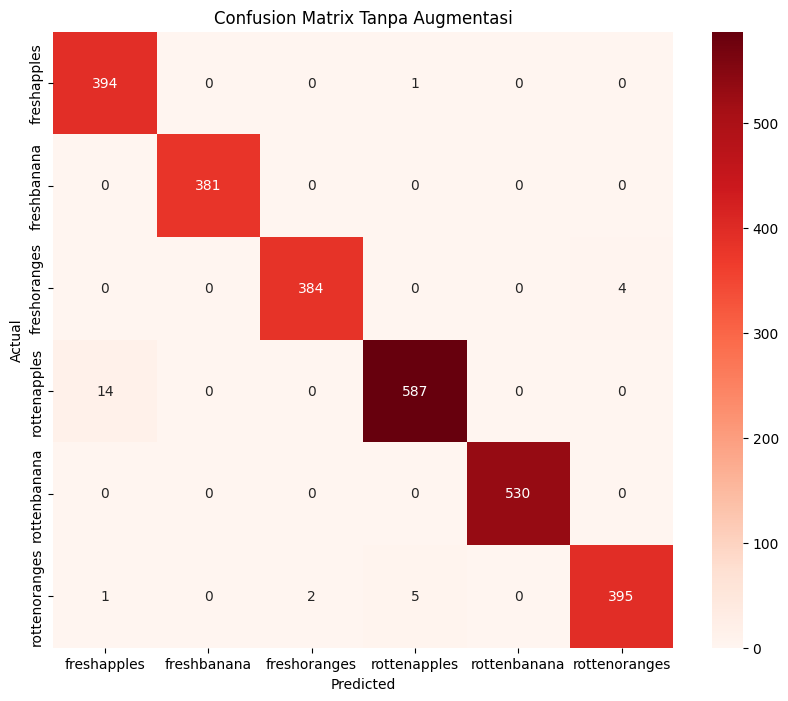

In [ ]:
# =========================================================
# CONFUSION MATRIX TANPA AUGMENTASI
# =========================================================

cm_no_aug = confusion_matrix(y_true_no_aug, y_pred_no_aug)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_no_aug,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names_no_aug,
    yticklabels=class_names_no_aug
)

plt.title("Confusion Matrix Tanpa Augmentasi")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


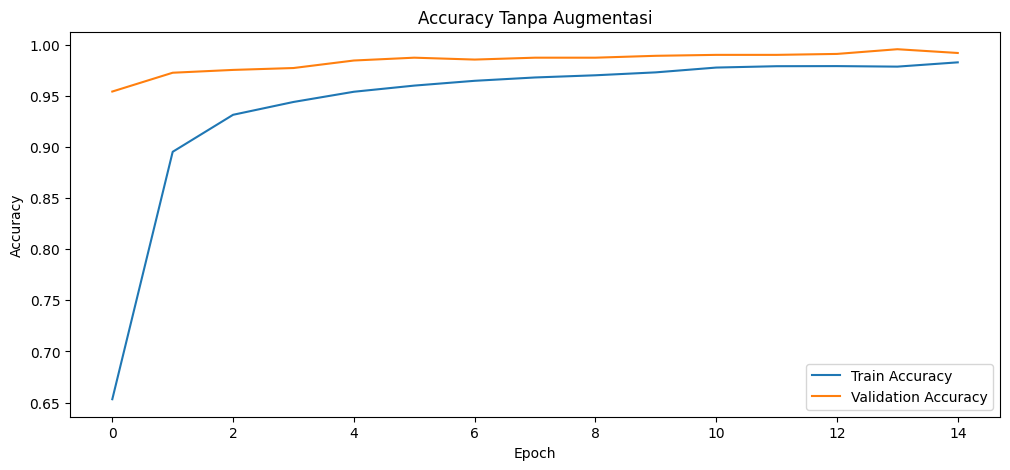

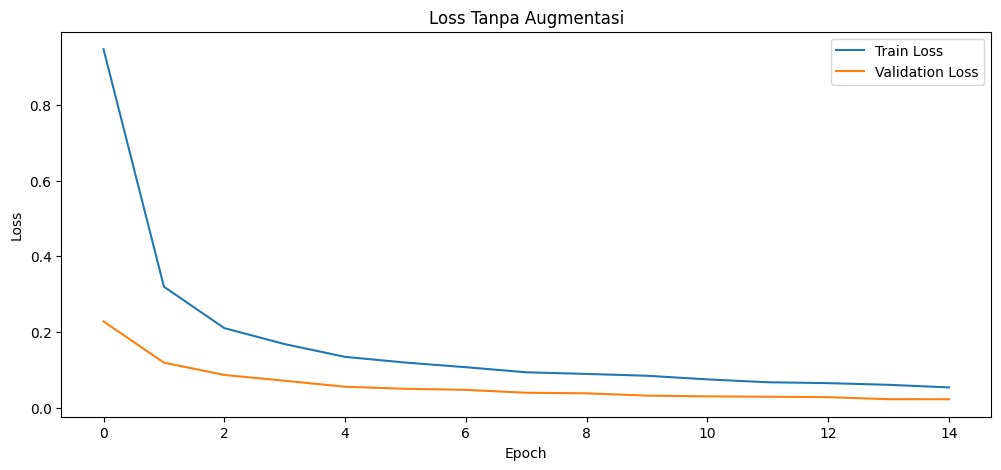

In [ ]:
# =========================================================
# GRAFIK ACCURACY TANPA AUGMENTASI
# =========================================================

plt.figure(figsize=(12,5))

plt.plot(
    history_no_aug.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_no_aug.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Tanpa Augmentasi")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# =========================================================
# GRAFIK LOSS TANPA AUGMENTASI
# =========================================================

plt.figure(figsize=(12,5))

plt.plot(
    history_no_aug.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_no_aug.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Tanpa Augmentasi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

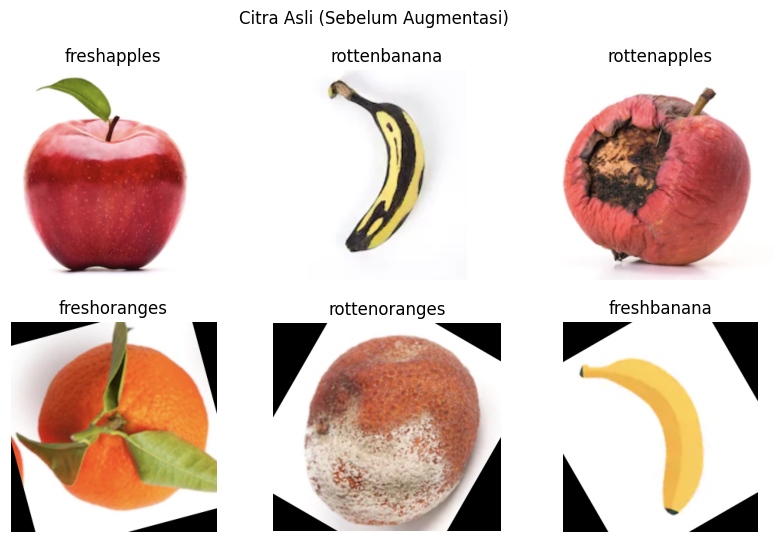

In [ ]:
# =========================================================
# MENAMPILKAN GAMBAR ASLI (3 JENIS BUAH)
# =========================================================

import cv2

def show_sample_images(directory, title):
    classes = os.listdir(directory)
    plt.figure(figsize=(10,6))

    for i, cls in enumerate(classes[:6]):
        img_path = os.path.join(directory, cls, os.listdir(os.path.join(directory, cls))[0])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

    plt.suptitle(title)
    plt.show()

show_sample_images(train_dir, "Citra Asli (Sebelum Augmentasi)")

AUGMENTASI

In [ ]:
# =========================================================
# DATA AUGMENTATION
# =========================================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
# =========================================================
# LOAD DATASET
# =========================================================

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 9813 images belonging to 6 classes.
Found 1088 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.


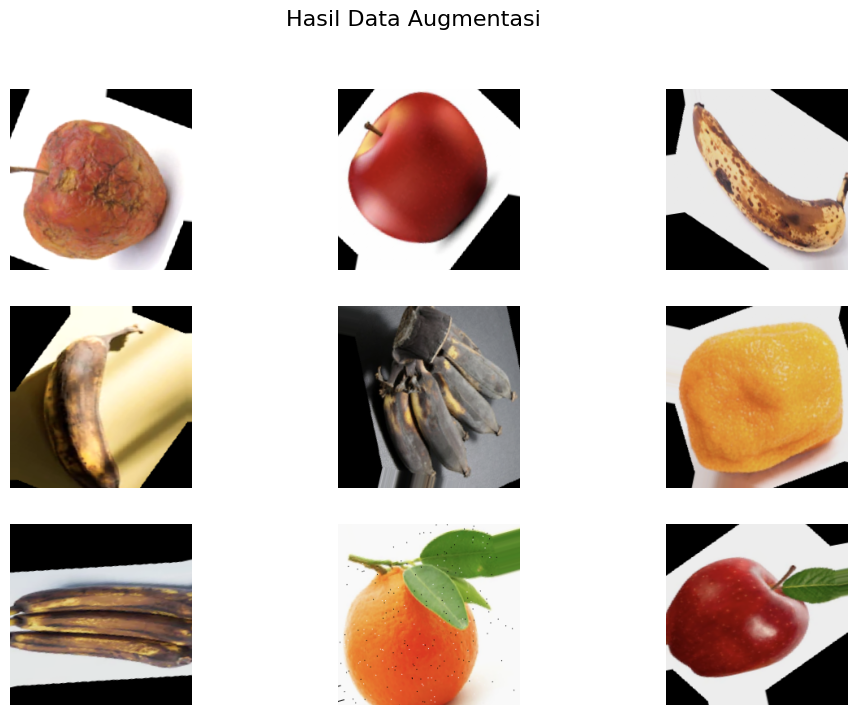

In [ ]:
# =========================================================
# MENAMPILKAN HASIL AUGMENTASI
# =========================================================

sample_images, sample_labels = next(train_generator)
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3,3,i+1)
    img = sample_images[i]

    # Mengembalikan tampilan gambar
    img = (img + 1) / 2
    plt.imshow(img)
    plt.axis('off')

plt.suptitle("Hasil Data Augmentasi", fontsize=16)
plt.show()

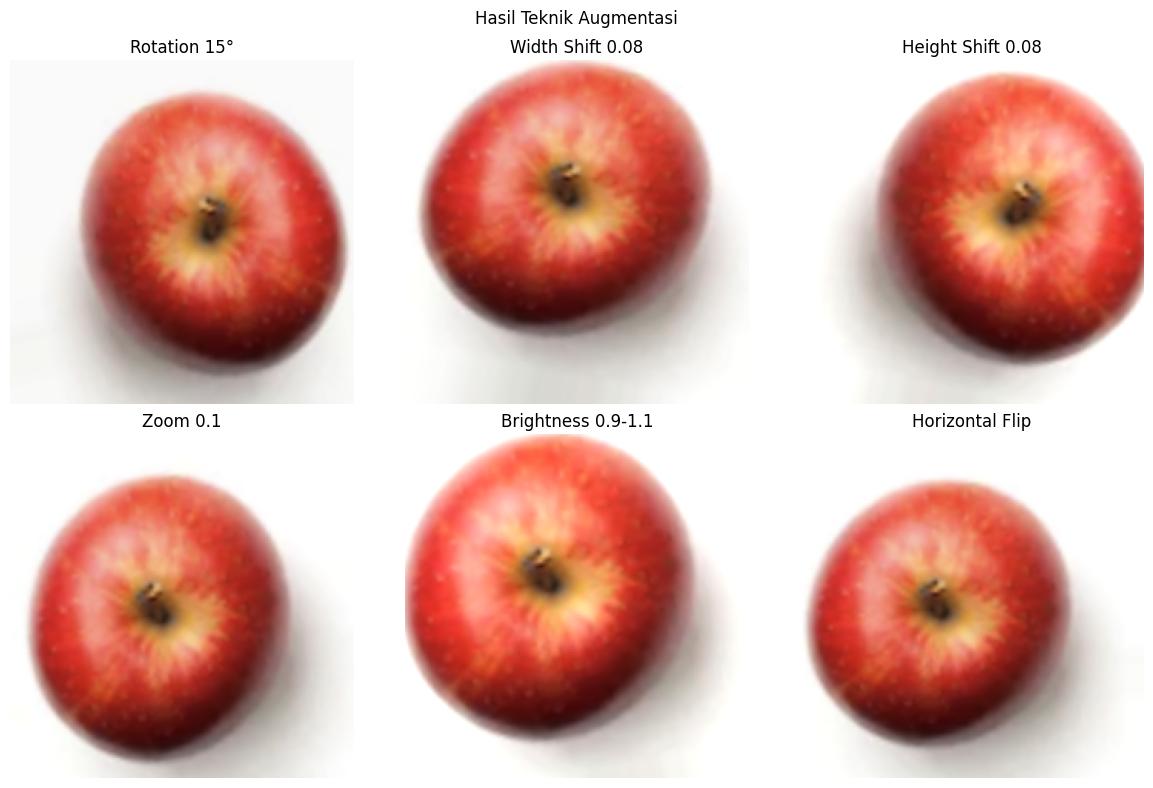

In [ ]:
# =========================================================
# MENAMPILKAN HASIL AUGMENTASI APPLE
# =========================================================

import cv2
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# augmentasi khusus visualisasi
visual_aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    brightness_range=[0.9,1.1],
    horizontal_flip=True
)

# pilih folder apple
class_name = 'freshapples'

class_path = os.path.join(train_dir, class_name)

# ambil gambar random
img_name = random.choice(os.listdir(class_path))

img_path = os.path.join(class_path, img_name)

# baca gambar
img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# resize
img = cv2.resize(img, IMG_SIZE)

# ubah jadi array
img_array = np.expand_dims(img, axis=0)

# augmentasi
aug_iter = visual_aug.flow(img_array, batch_size=1)

augmentasi_labels = [
    "Rotation 15°",
    "Width Shift 0.08",
    "Height Shift 0.08",
    "Zoom 0.1",
    "Brightness 0.9-1.1",
    "Horizontal Flip"
]

plt.figure(figsize=(12,8))

for i in range(6):

    aug_img = next(aug_iter)[0].astype("uint8")

    plt.subplot(2,3,i+1)

    plt.imshow(aug_img)

    plt.title(augmentasi_labels[i])

    plt.axis('off')

plt.suptitle("Hasil Teknik Augmentasi")

plt.tight_layout()

plt.show()

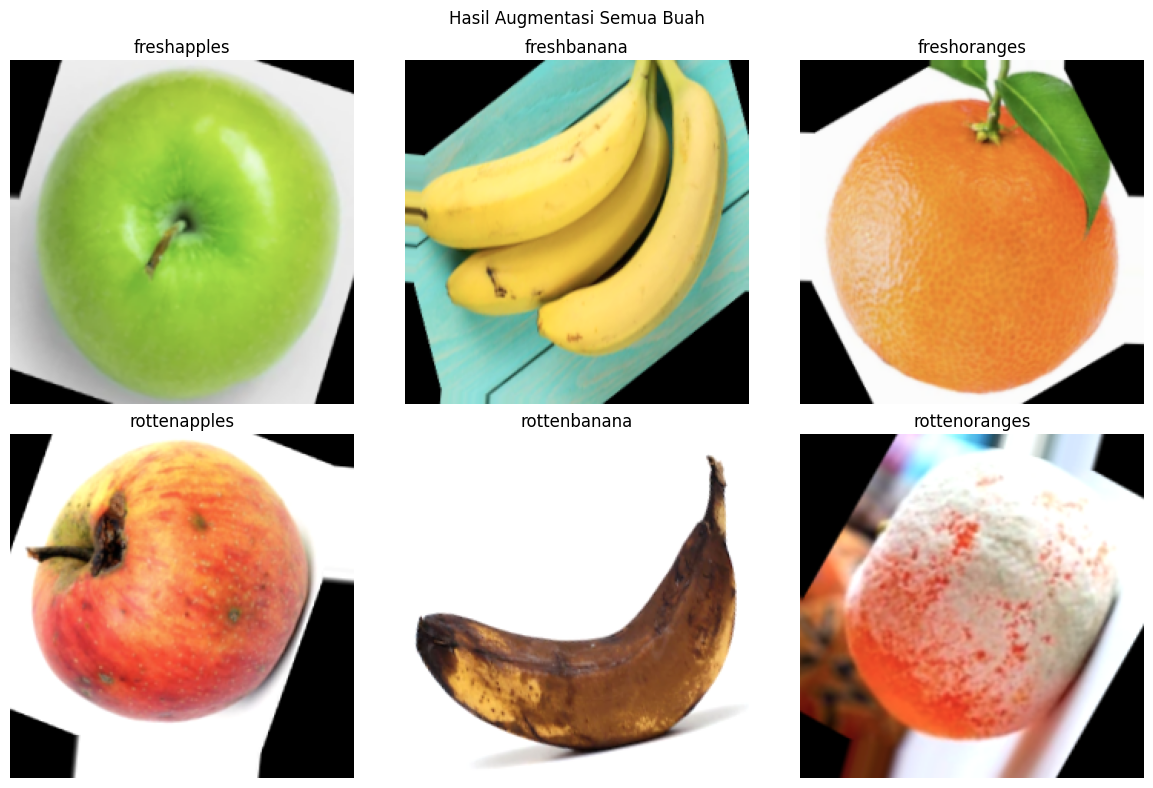

In [ ]:
# =========================================================
# MENAMPILKAN HASIL AUGMENTASI SEMUA BUAH
# =========================================================

import cv2
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# augmentasi khusus visualisasi
visual_aug = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    brightness_range=[0.9,1.1],
    horizontal_flip=True
)

# daftar kelas buah
classes = [
    'freshapples',
    'freshbanana',
    'freshoranges',
    'rottenapples',
    'rottenbanana',
    'rottenoranges'
]

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_dir, class_name)

    # ambil gambar random
    img_name = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    # baca gambar
    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # resize
    img = cv2.resize(img, IMG_SIZE)

    # ubah jadi array
    img_array = np.expand_dims(img, axis=0)

    # augmentasi
    aug_iter = visual_aug.flow(img_array, batch_size=1)

    aug_img = next(aug_iter)[0].astype("uint8")

    plt.subplot(2,3,i+1)

    plt.imshow(aug_img)

    plt.title(class_name)

    plt.axis('off')

plt.suptitle("Hasil Augmentasi Semua Buah")

plt.tight_layout()

plt.show()

In [ ]:
# =========================================================
# MEMBUAT MODEL MOBILENETV2
# =========================================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_model.trainable = False

In [ ]:
# =========================================================
# MEMBUAT MODEL CNN
# =========================================================

model = models.Sequential([

    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(
        train_generator.num_classes,
        activation='softmax'
    )
])

In [ ]:
# =========================================================
# MENAMPILKAN ARSITEKTUR MODEL
# =========================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# =========================================================
# CALLBACK
# =========================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
# =========================================================
# TRAINING AWAL
# =========================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)


Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4635 - loss: 1.4367
Epoch 1: val_accuracy improved from None to 0.94945, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.6597 - loss: 0.9309 - val_accuracy: 0.9494 - val_loss: 0.2509 - learning_rate: 1.0000e-04
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8809 - loss: 0.3550
Epoch 2: val_accuracy improved from 0.94945 to 0.96783, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8935 - loss: 0.3171 - val_accuracy: 0.9678 - val_loss: 0.1267 - learning_rate: 1.0000e-04
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9258 - loss: 0.2230
Epoch 3: val_accuracy improved from 0.96783 to 0.97151, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9305 - loss: 0.2114 - val_accuracy: 0.9715 - val_loss: 0.0978 - learning_rate: 1.0000e-04
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9430 - loss: 0.1747
Epoch 4: val_accuracy improved from 0.97151 to 0.97335, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9447 - loss: 0.1692 - val_accuracy: 0.9733 - val_loss: 0.0762 - learning_rate: 1.0000e-04
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9525 - loss: 0.1498
Epoch 5: val_accuracy improved from 0.97335 to 0.97978, saving model to best_model.h5


...


Epoch 7: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9624 - loss: 0.1135 - val_accuracy: 0.9890 - val_loss: 0.0435 - learning_rate: 1.0000e-04
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9646 - loss: 0.1035
Epoch 8: val_accuracy improved from 0.98897 to 0.99081, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.9657 - loss: 0.1025 - val_accuracy: 0.9908 - val_loss: 0.0403 - learning_rate: 1.0000e-04
Epoch 9/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9653 - loss: 0.1048
Epoch 9: val_accuracy did not improve from 0.99081
154/154 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9683 - loss: 0.0969 - val_accuracy: 0.9881 - val_loss: 0.0380 - learning_rate: 1.0000e-04
Epoch 10/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9717 - loss: 0.0903
Epoch 10: val_accuracy improved from 0.99081 to 0.99173, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9731 - loss: 0.0863 - val_accuracy: 0.9917 - val_loss: 0.0367 - learning_rate: 1.0000e-04
Epoch 11/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9727 - loss: 0.0846
Epoch 11: val_accuracy did not improve from 0.99173
154/154 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9729 - loss: 0.0833 - val_accuracy: 0.9899 - val_loss: 0.0324 - learning_rate: 1.0000e-04
Epoch 12/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9768 - loss: 0.0783
Epoch 12: val_accuracy improved from 0.99173 to 0.99449, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9738 - loss: 0.0783 - val_accuracy: 0.9945 - val_loss: 0.0285 - learning_rate: 1.0000e-04
Epoch 13/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9741 - loss: 0.0773
Epoch 13: val_accuracy did not improve from 0.99449
154/154 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9756 - loss: 0.0738 - val_accuracy: 0.9945 - val_loss: 0.0260 - learning_rate: 1.0000e-04
Epoch 14/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9763 - loss: 0.0732
Epoch 14: val_accuracy did not improve from 0.99449
154/154 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9771 - loss: 0.0708 - val_accuracy: 0.9945 - val_loss: 0.0268 - learning_rate: 1.0000e-04
Epoch 15/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9797 - loss: 0.0615
Epoch 15: val_accuracy improved from 0.99449 to 0.99540, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
154/154 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9787 - loss: 0.0647 - val_accuracy: 0.9954 - val_loss: 0.0224 - learning_rate: 1.0000e-04


In [ ]:
# =========================================================
# FINE TUNING
# =========================================================

base_model.trainable = True

# Freeze sebagian layer awal
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
# =========================================================
# COMPILE ULANG
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# =========================================================
# TRAINING FINE TUNING
# =========================================================

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.4948 - loss: 1.3802 - val_accuracy: 0.6866 - val_loss: 0.9034 - learning_rate: 1.0000e-05
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.8277 - loss: 0.5633 - val_accuracy: 0.8438 - val_loss: 0.5242 - learning_rate: 1.0000e-05
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.9099 - loss: 0.3145 - val_accuracy: 0.9007 - val_loss: 0.3518 - learning_rate: 1.0000e-05
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9413 - loss: 0.2092 - val_accuracy: 0.9191 - val_loss: 0.2397 - learning_rate: 1.0000e-05
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9543 - loss: 0.1530 - val_accuracy: 0.9513 - val_loss: 0.1582 - learning_rate: 1.0000e-05
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9660 - loss: 0.1196 - val_accuracy: 0.9660 - val_loss: 0.1018 - learning_rate: 1.0000e-05
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - acc

In [ ]:
# =========================================================
# EVALUASI MODEL
# =========================================================

test_loss, test_acc = model.evaluate(test_generator)

print("\n===================================")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("===================================")


43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 666ms/step - accuracy: 0.9933 - loss: 0.0235

Test Accuracy : 0.9933
Test Loss     : 0.0235


In [ ]:
# =========================================================
# PREDIKSI DATA TEST
# =========================================================

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_names = list(
    test_generator.class_indices.keys()
)

43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 462ms/step


In [ ]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nCLASSIFICATION REPORT\n")
print(

    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


CLASSIFICATION REPORT

               precision    recall  f1-score   support

  freshapples       0.98      1.00      0.99       395
  freshbanana       0.99      1.00      1.00       381
 freshoranges       0.99      0.99      0.99       388
 rottenapples       0.99      0.99      0.99       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       1.00      0.99      0.99       403

     accuracy                           0.99      2698
    macro avg       0.99      0.99      0.99      2698
 weighted avg       0.99      0.99      0.99      2698



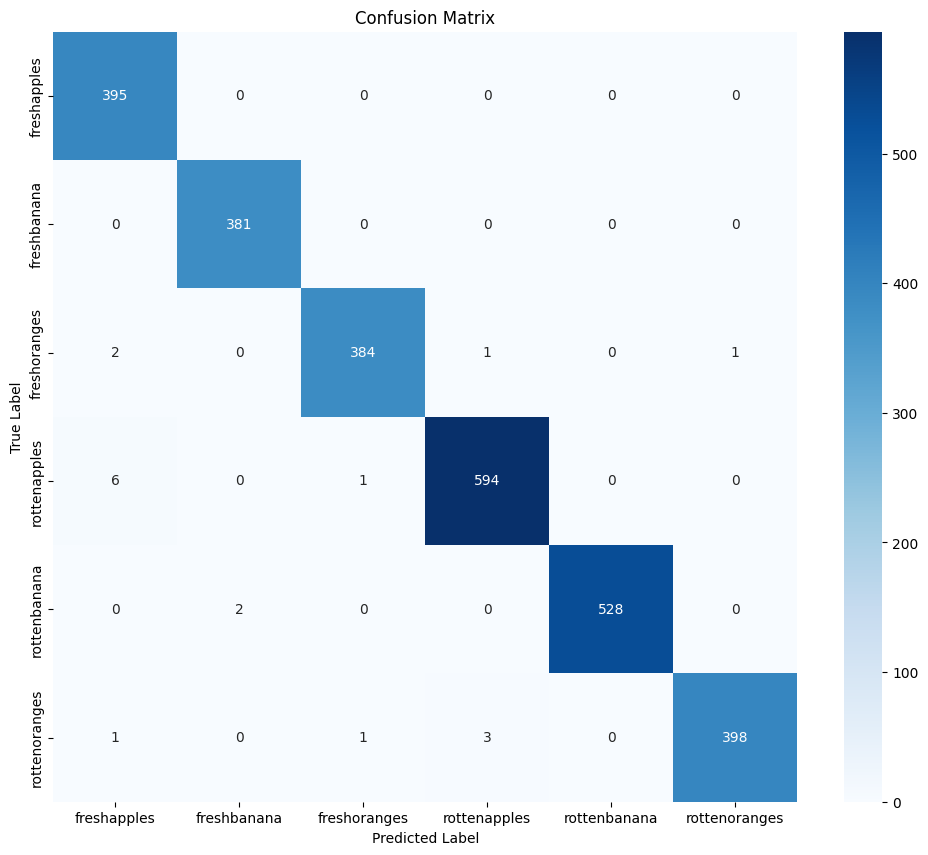

In [ ]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

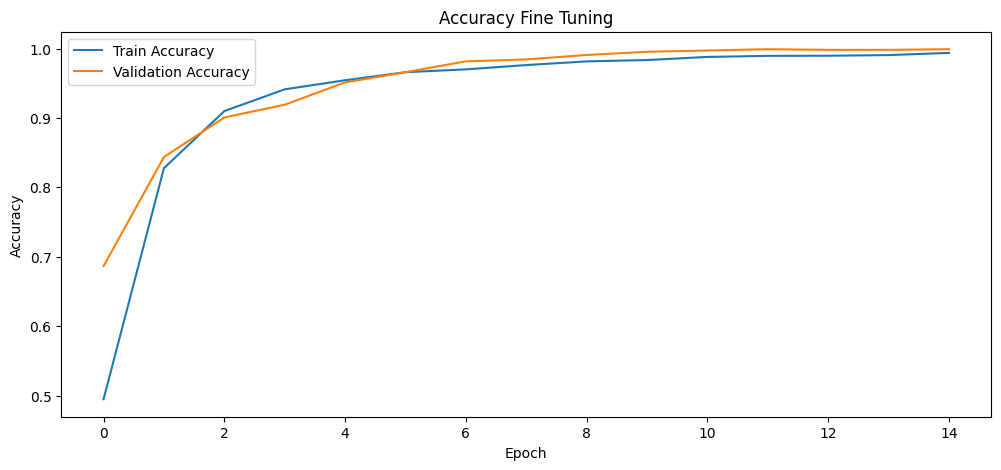

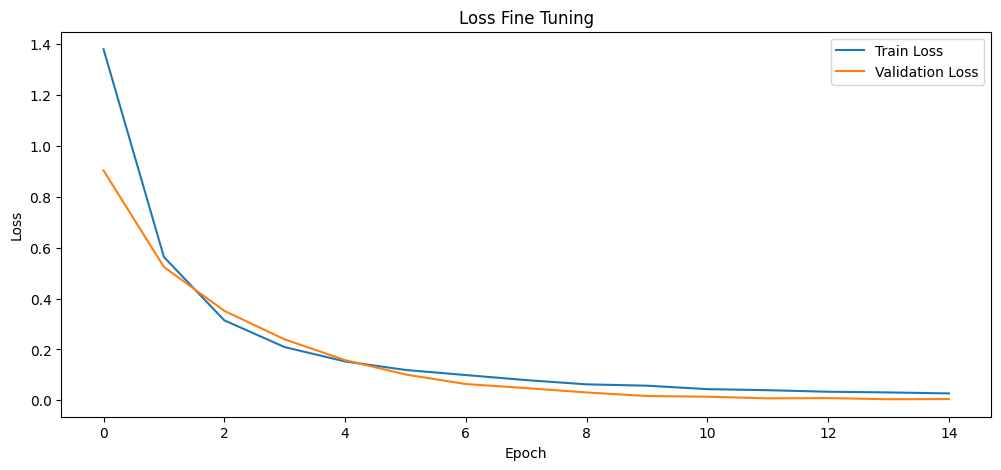

In [ ]:
# =========================================================
# GRAFIK ACCURACY FINE TUNING
# =========================================================

plt.figure(figsize=(12,5))

plt.plot(
    history_finetune.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_finetune.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Fine Tuning")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# =========================================================
# GRAFIK LOSS FINE TUNING
# =========================================================

plt.figure(figsize=(12,5))

plt.plot(
    history_finetune.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_finetune.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Fine Tuning")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()